<a href="https://colab.research.google.com/github/Abhinaytechie/LangGraph/blob/main/Langraph_Chatbot_withTools.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langgraph langchain langsmith langchain-community langchain-groq

In [ ]:
from google.colab import userdata
groq_api_key=userdata.get('GROQ_API_KEY')
langsmith=userdata.get('LANGSMITH_API_KEY')
import os
os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["LANGCHAIN_API_KEY"]=langsmith
os.environ["LANGCHAIN_PROJECT"]="langgraph-Chatbot_demo"

In [ ]:
from langchain_groq import ChatGroq

llm=ChatGroq(model='meta-llama/llama-4-scout-17b-16e-instruct',groq_api_key=groq_api_key)


In [ ]:
!pip install arxiv wikipedia

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

In [ ]:
#Working with tools
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun

arxiv_wrapper=ArxivAPIWrapper(top_k_results=1,doc_content_chars_max=300)
arxiv_tool=ArxivQueryRun(api_wrapper=arxiv_wrapper)

wikipedia_wrapper=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=300)
wikipedia_tool=WikipediaQueryRun(api_wrapper=wikipedia_wrapper)
tools=[arxiv_tool,wikipedia_tool]

In [ ]:
from langgraph.graph import add_messages
class State(TypedDict):
  messages:Annotated[list,add_messages]

In [ ]:
from langgraph.graph import StateGraph,START,END

In [ ]:
graph_builder=StateGraph(State)

In [ ]:
llm_with_tools=llm.bind_tools(tools=tools)

In [ ]:
def chatbot(state:State):
  return {'messages':[llm_with_tools.invoke(state['messages'])]}


In [ ]:
from langgraph.prebuilt import ToolNode,tools_condition


In [ ]:
graph_builder.add_node("Chatbot",chatbot)
graph_builder.add_edge(START,"Chatbot")
tool_node=ToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)
graph_builder.add_conditional_edges(
    "Chatbot",
    tools_condition
)
graph_builder.add_edge("tools","Chatbot")
graph_builder.add_edge("Chatbot",END)

In [ ]:
graph=graph_builder.compile()

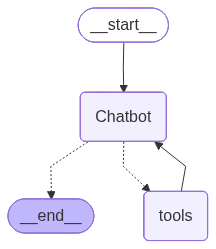

In [ ]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
user_input="Hi tell me about Attention is all you need"
events=graph.stream(
    {'messages':['user',user_input]},stream_mode="values"
)

for event in events:
  print("||||||||||||||||||||||||||||")
  event['messages'][-1].pretty_print()
  print("||||||||||||||||||||||||||||")

||||||||||||||||||||||||||||
================================ Human Message =================================

Hi tell me about Attention is all you need
||||||||||||||||||||||||||||
||||||||||||||||||||||||||||
================================== Ai Message ==================================
Tool Calls:
  arxiv (1fjywv9zc)
 Call ID: 1fjywv9zc
  Args:
    query: Attention is all you need
||||||||||||||||||||||||||||
||||||||||||||||||||||||||||
================================= Tool Message =================================
Name: arxiv

Published: 2024-07-22
Title: Attention Is All You Need But You Don't Need All Of It For Inference of Large Language Models
Authors: Georgy Tyukin, Gbetondji J-S Dovonon, Jean Kaddour, Pasquale Minervini
Summary: The inference demand for LLMs has skyrocketed in recent months, and serving
models with 
||||||||||||||||||||||||||||
||||||||||||||||||||||||||||
================================== Ai Message ==================================

The paper "Attent